In [1]:
import rasterio
import shreklib
import os
from os.path import join
import glob

In [4]:
s1_mensuel_folder="/mnt/Data/30_Stages_Encours/2026/2026_SHREQ_Niels/02_Donnees/input/Sentinel1/Haute_Garonne/gee_S1_intensite/s1_mensuel_db"
fps=glob.glob(join(s1_mensuel_folder, "*.tif"))
out_folder="/mnt/Data/30_Stages_Encours/2026/2026_SHREQ_Niels/02_Donnees_propres/S1/S1_mensuel"

In [2]:
with rasterio.open("/mnt/Data/30_Stages_Encours/2026/2026_SHREQ_Niels/02_Donnees_propres/S1/S1_mensuel/D_VV_mensuel_db.tif", "r") as src:
    d_vv=src.read(5)

In [3]:
with rasterio.open("/mnt/Data/30_Stages_Encours/2026/2026_SHREQ_Niels/02_Donnees_propres/S1/S1_mensuel/A_VV_mensuel_db.tif", "r") as src:
    a_vv=src.read(5)

In [4]:
with rasterio.open("/mnt/Data/30_Stages_Encours/2026/2026_SHREQ_Niels/02_Donnees_propres/S1/S1_mensuel/D_VH_mensuel_db.tif", "r") as src:
    d_vh=src.read(5)

In [5]:
with rasterio.open("/mnt/Data/30_Stages_Encours/2026/2026_SHREQ_Niels/02_Donnees_propres/S1/S1_mensuel/a_VH_mensuel_db.tif", "r") as src:
    a_vh=src.read(5)

In [6]:
a_vh.dtype

dtype('float32')

In [9]:
with rasterio.open("/mnt/Data/30_Stages_Encours/2026/2026_SHREQ_Niels/02_Donnees/modeles/reauzoh4/lst_medianes_saisonnieres.tif", "r") as src:
    landsat=src.read()

In [7]:
import numpy as np

In [8]:
shreklib.tif_export(np.stack([d_vv, d_vh, a_vv, a_vh]), shreklib.ref_grid["transform"], 32631, "/mnt/Data/30_Stages_Encours/2026/2026_SHREQ_Niels/s1_month5_dvv_d_vh_a_vv_a_vh.tif", "float32")

In [ ]:
from tqdm import tqdm
for fp in tqdm(fps):
    if fp=='/mnt/Data/30_Stages_Encours/2026/2026_SHREQ_Niels/02_Donnees/input/Sentinel1/Haute_Garonne/gee_S1_intensite/s1_mensuel_db/D_VV_mensuel_db.tif':
        continue
    name=os.path.basename(fp)
    with rasterio.open(fp, "r") as src:
        img=src.read()
    shreklib.tif_export(img, shreklib.ref_grid["transform"], 32631, join(out_folder, name), "float32")

 67%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████                                                                   | 4/6 [32:33<17:47, 533.72s/it]

In [2]:
import pandas as pd
import re
import numpy as np

In [13]:
latex="""métrique & Non Zone Humide & Zone Humide & moyenne\\
\hline
précision &45.9 $\pm$ 0.3\%&91.3 $\pm$ 0.1\%&68.6 $\pm$ 0.2\%\\
\hline
rappel &66.4 $\pm$ 0.3\%&61.9 $\pm$ 0.3\%&74.2 $\pm$ 0.3\%\\
\hline
F1-Score &54.3 $\pm$ 0.1\%&86.4 $\pm$ 0.1\%&70.3 $\pm$ 0.1\%\\"""

<>:1: SyntaxWarning: invalid escape sequence '\h'
<>:1: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_2770998/845492151.py:1: SyntaxWarning: invalid escape sequence '\h'
  latex="""métrique & Non Zone Humide & Zone Humide & moyenne\\


In [3]:
out_folder="/mnt/Data/30_Stages_Encours/2026/2026_SHREQ_Niels/05_Rapport/graphiques/soutenance"

In [4]:
from os.path import join

In [5]:
def tex_to_xlsx(latex, out_name):
    tab_arr=np.array([line.split("&") for line in latex.replace("""\hline""", "").replace("""$\\pm$""", "±").replace("""\\%""", "%").split("""\\\n\n""")])
    pd.DataFrame(tab_arr[1:], columns=tab_arr[0]).to_excel(join(out_folder, out_name+".xlsx"), index=False)

<>:2: SyntaxWarning: invalid escape sequence '\h'
<>:2: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_4014778/986656749.py:2: SyntaxWarning: invalid escape sequence '\h'
  tab_arr=np.array([line.split("&") for line in latex.replace("""\hline""", "").replace("""$\\pm$""", "±").replace("""\\%""", "%").split("""\\\n\n""")])


In [7]:
latex="""métrique & Non Zone Humide & Zone Humide & moyenne\\
\hline
précision &45 $\pm$ 0.2\%&90.3 $\pm$ 0.1\%&67.6 $\pm$ 0.1\%\\
\hline
rappel &61.5 $\pm$ 0.4\%&82.6 $\pm$ 0.3\%&72.1 $\pm$ 0.4\%\\
\hline
F1-Score &52 $\pm$ 0\%&86.3 $\pm$ 0.1\%&69.1 $\pm$ 0.1\%\\"""
tex_to_xlsx(latex, "fort_ndvi_nisar_metrics_temoin")

<>:1: SyntaxWarning: invalid escape sequence '\h'
<>:1: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_4014778/931390560.py:1: SyntaxWarning: invalid escape sequence '\h'
  latex="""métrique & Non Zone Humide & Zone Humide & moyenne\\


In [41]:
with rasterio.open("/mnt/Data/30_Stages_Encours/2026/2026_SHREQ_Niels/02_Donnees/modeles/reauzoh4/lst_medianes_saisonnieres.tif", "r") as src:
    landsat=src.read()

In [42]:
landsat_monthed=np.concat([[band, band, band] for band in landsat])

In [48]:
landsat_monthed[3,5000, 7000]

np.float64(33.10239055330834)

In [49]:
out_folder="/mnt/Data/30_Stages_Encours/2026/2026_SHREQ_Niels/02_Donnees_propres/LST"
shreklib.tif_export(landsat_monthed.astype(np.float32), shreklib.ref_grid["transform"], 32631, join(out_folder, "landsat_lst_medianes_saisonnieres.tif"), "float32")

In [50]:
import torch
torch.no_grad()
landsat_tens=torch.from_numpy(landsat)
lst_valid_mask=~torch.all(torch.isnan(landsat_tens), dim=0)

In [52]:
import matplotlib.pyplot as plt

/usr/local/lib/python3.12/dist-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [55]:
shreklib.tif_export(lst_valid_mask.type(torch.uint8).numpy(), shreklib.ref_grid["transform"], 32631, join(out_folder, "lst_valid_mask.tif"), "uint8")

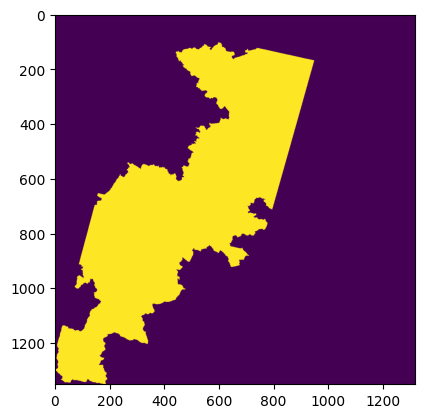

In [53]:
plt.imshow(shreklib.downsample_img(lst_valid_mask.numpy(), how="max"))